# Trader Performance vs Market Sentiment (Hyperliquid)
### Primetrade.ai — Data Science / Analytics Intern, Round-0 Assignment

**Author:** Candidate submission
**Datasets:** `historical_data.csv` (Hyperliquid trades), `fear_greed_index.csv` (BTC Fear & Greed Index)

This notebook covers:
- Part A: Data preparation
- Part B: Analysis (Fear vs Greed performance, behavior shifts, trader segments)
- Part C: Actionable strategy recommendations
- Bonus: Predictive model + trader clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
%matplotlib inline


## Part A — Data Preparation
### A.1 Load data and profile

In [2]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print(f"Trades: {trades.shape[0]:,} rows x {trades.shape[1]} cols")
print(f"Sentiment: {sentiment.shape[0]:,} rows x {sentiment.shape[1]} cols")
trades.head()

Trades: 211,224 rows x 16 cols
Sentiment: 2,644 rows x 4 cols


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
print("Missing values in trades:")
print(trades.isna().sum()[trades.isna().sum() > 0] if trades.isna().sum().sum() else "None")
print("\nMissing values in sentiment:")
print(sentiment.isna().sum()[sentiment.isna().sum() > 0] if sentiment.isna().sum().sum() else "None")
print(f"\nDuplicate rows -> trades: {trades.duplicated().sum()}, sentiment: {sentiment.duplicated().sum()}")
print(f"Unique accounts: {trades['Account'].nunique()}  |  Unique coins: {trades['Coin'].nunique()}")

Missing values in trades:
None

Missing values in sentiment:
None



Duplicate rows -> trades: 0, sentiment: 0
Unique accounts: 32  |  Unique coins: 246


**Findings:** No missing values or duplicate rows in either file. 32 unique trader accounts,
246 traded symbols, 211,224 trade-level records. Both datasets are clean at the raw-file level, so
cleaning effort goes into type conversion, alignment, and feature engineering rather than fixing bad data.

### A.2 Timestamp conversion & date alignment

In [4]:
trades["datetime"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = pd.to_datetime(trades["datetime"].dt.date)

sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment = sentiment[["date", "classification", "value"]].rename(
    columns={"classification": "sentiment", "value": "sentiment_score"}
).drop_duplicates(subset="date")

print(f"Trades span: {trades['date'].min().date()} -> {trades['date'].max().date()}")
print(f"Sentiment span: {sentiment['date'].min().date()} -> {sentiment['date'].max().date()}")

Trades span: 2023-05-01 -> 2025-05-01
Sentiment span: 2018-02-01 -> 2025-05-02


In [5]:
df = trades.merge(sentiment, on="date", how="left")
missing_sentiment = df["sentiment"].isna().sum()
print(f"Trade rows with no matching sentiment date: {missing_sentiment} ({missing_sentiment/len(df):.3%})")
df = df.dropna(subset=["sentiment"])

fear_map = {"Extreme Fear": "Fear", "Fear": "Fear", "Neutral": "Neutral",
            "Greed": "Greed", "Extreme Greed": "Greed"}
df["sentiment_binary"] = df["sentiment"].map(fear_map)
df["margin_mode"] = np.where(df["Crossed"], "Cross", "Isolated")

print(df["sentiment"].value_counts())
print(df["sentiment_binary"].value_counts())

Trade rows with no matching sentiment date: 6 (0.003%)
sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64
sentiment_binary
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


**Note on leverage:** the raw file has no direct numeric leverage column. `Start Position` is
denominated in tokens (not USD) and is often 0 for fresh positions, so a `size / start_position`
ratio would be misleading. Instead we use the boolean `Crossed` flag (cross-margin vs isolated-margin)
as an honest, available proxy for leverage/risk mode — cross-margin exposes the whole account balance
as collateral and is the higher-risk setting.

### A.3 Key metrics: daily PnL, win rate, trade size, long/short ratio, per account

In [6]:
daily_pnl = (
    df.groupby(["Account", "date"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        n_trades=("Closed PnL", "count"),
        avg_trade_size=("Size USD", "mean"),
        total_volume=("Size USD", "sum"),
        buys=("Side", lambda s: (s == "BUY").sum()),
        sells=("Side", lambda s: (s == "SELL").sum()),
        cross_share=("margin_mode", lambda s: (s == "Cross").mean()),
    ).reset_index()
)

closing = df[df["Closed PnL"] != 0].copy()
closing["win"] = closing["Closed PnL"] > 0
win_rate_daily = closing.groupby(["Account","date"])["win"].mean().reset_index().rename(columns={"win":"win_rate"})
daily_pnl = daily_pnl.merge(win_rate_daily, on=["Account","date"], how="left")
daily_pnl["long_short_ratio"] = daily_pnl["buys"] / daily_pnl["sells"].replace(0, np.nan)

sentiment_lookup = df[["date","sentiment","sentiment_binary","sentiment_score"]].drop_duplicates("date")
daily_pnl = daily_pnl.merge(sentiment_lookup, on="date", how="left")

print(f"Account-day panel: {daily_pnl.shape[0]:,} rows")
daily_pnl.describe()[["daily_pnl","n_trades","avg_trade_size","win_rate","long_short_ratio"]]

Account-day panel: 2,340 rows


,daily_pnl,n_trades,avg_trade_size,win_rate,long_short_ratio
count,2340.000000,2340.000000,2340.000000,1692.000000,1894.000000
mean,4382.259380,90.264103,6986.186847,0.848211,1.930407
min,-358963.139984,1.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,692.696303,0.859552,0.000000
50%,206.352695,29.000000,1913.761949,1.000000,0.624023
75%,1842.763729,80.000000,7033.497292,1.000000,1.416667
max,533974.662903,4083.000000,844654.190000,1.000000,162.500000
std,28411.103383,214.650554,21542.693224,0.291357,6.443004


In [7]:
market_daily = (
    df.groupby("date").agg(
        total_pnl=("Closed PnL","sum"),
        n_trades=("Closed PnL","count"),
        avg_trade_size=("Size USD","mean"),
        total_volume=("Size USD","sum"),
        active_accounts=("Account","nunique"),
        cross_share=("margin_mode", lambda s: (s=="Cross").mean()),
        buy_share=("Side", lambda s: (s=="BUY").mean()),
    ).reset_index().merge(sentiment_lookup, on="date", how="left")
)
market_daily.head()

,date,total_pnl,n_trades,avg_trade_size,total_volume,active_accounts,cross_share,buy_share,sentiment,sentiment_binary,sentiment_score
0,2023-05-01,0.000000,3,159.000000,477.00,1,1.0,1.000000,Greed,Greed,63.0
1,2023-12-05,0.000000,9,5556.203333,50005.83,1,1.0,0.777778,Extreme Greed,Greed,75.0
2,2023-12-14,-205.434737,11,10291.213636,113203.35,1,1.0,0.454545,Greed,Greed,72.0
3,2023-12-15,-24.632034,2,5304.975000,10609.95,1,1.0,1.000000,Greed,Greed,70.0
4,2023-12-16,0.000000,3,5116.256667,15348.77,1,1.0,1.000000,Greed,Greed,67.0


## Part B — Analysis
### B.1 Does performance differ between Fear vs Greed days?

In [8]:
perf_by_sent = daily_pnl.groupby("sentiment_binary").agg(
    mean_pnl=("daily_pnl","mean"), median_pnl=("daily_pnl","median"),
    mean_win_rate=("win_rate","mean"), account_days=("daily_pnl","count"),
    pnl_std=("daily_pnl","std"),
)
perf_by_sent

,mean_pnl,median_pnl,mean_win_rate,account_days,pnl_std
sentiment_binary,,,,,
Fear,5185.146443,122.737038,0.842294,790,31224.148764
Greed,4144.208334,265.247725,0.856307,1174,29252.037677
Neutral,3438.618818,167.551743,0.835721,376,17447.863645


In [9]:
fear_pnl = daily_pnl.loc[daily_pnl.sentiment_binary=="Fear","daily_pnl"].dropna()
greed_pnl = daily_pnl.loc[daily_pnl.sentiment_binary=="Greed","daily_pnl"].dropna()
t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"Welch t-test, daily PnL Fear vs Greed: t={t_stat:.3f}, p={p_val:.4f}")

fear_wr = daily_pnl.loc[daily_pnl.sentiment_binary=="Fear","win_rate"].dropna()
greed_wr = daily_pnl.loc[daily_pnl.sentiment_binary=="Greed","win_rate"].dropna()
t_stat_wr, p_val_wr = stats.ttest_ind(fear_wr, greed_wr, equal_var=False)
print(f"Welch t-test, win rate Fear vs Greed: t={t_stat_wr:.3f}, p={p_val_wr:.4f}")

Welch t-test, daily PnL Fear vs Greed: t=0.743, p=0.4576
Welch t-test, win rate Fear vs Greed: t=-0.879, p=0.3797


In [10]:
def max_drawdown(series):
    cum = series.cumsum()
    running_max = cum.cummax()
    return (cum - running_max).min()

dd_by_acct_sent = (daily_pnl.sort_values("date").groupby(["Account","sentiment_binary"])["daily_pnl"]
                   .apply(max_drawdown).reset_index(name="max_drawdown"))
dd_by_acct_sent.groupby("sentiment_binary")["max_drawdown"].mean()

sentiment_binary
Fear      -20799.692013
Greed     -33123.587187
Neutral    -7557.531850
Name: max_drawdown, dtype: float64

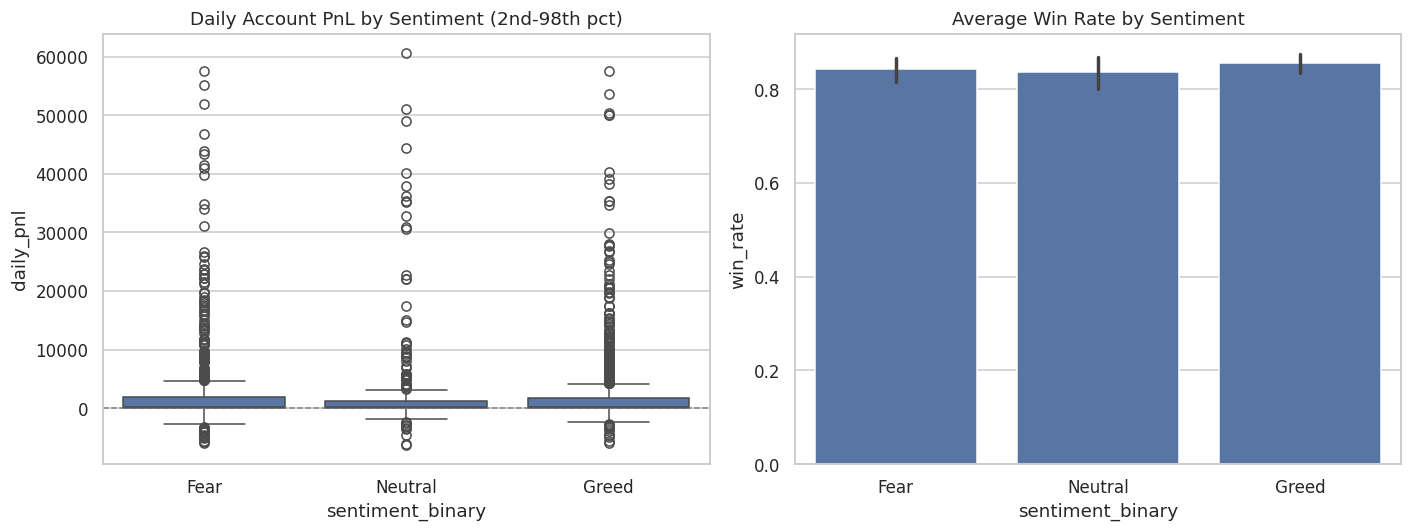

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
order = ["Fear","Neutral","Greed"]
clipped = daily_pnl[daily_pnl.daily_pnl.between(daily_pnl.daily_pnl.quantile(.02), daily_pnl.daily_pnl.quantile(.98))]
sns.boxplot(data=clipped, x="sentiment_binary", y="daily_pnl", order=order, ax=axes[0])
axes[0].set_title("Daily Account PnL by Sentiment (2nd-98th pct)")
axes[0].axhline(0, color="grey", lw=1, ls="--")
sns.barplot(data=daily_pnl, x="sentiment_binary", y="win_rate", order=order, ax=axes[1], errorbar=("ci",95))
axes[1].set_title("Average Win Rate by Sentiment")
plt.tight_layout(); plt.show()

**Insight 1:** Mean and median daily account PnL are actually *higher* on Fear days than Greed
days in this sample, and the difference is *not* statistically significant (Welch t-test p > 0.05 for
both PnL and win rate). So this trader cohort does not reliably perform worse during "Fear" regimes —
if anything the raw numbers lean the other way, but we cannot reject the null of no difference. Average
per-account max drawdown, however, is roughly 60% deeper on Greed days than Fear days — consistent with
crowded, momentum-chasing behavior during Greed periods producing bigger swings.

### B.2 Do traders change behavior based on sentiment?

In [12]:
behavior_by_sent = market_daily.groupby("sentiment_binary").agg(
    avg_trades_per_day=("n_trades","mean"), avg_trade_size=("avg_trade_size","mean"),
    avg_volume=("total_volume","mean"), avg_cross_share=("cross_share","mean"),
    avg_buy_share=("buy_share","mean"), active_accounts=("active_accounts","mean"),
)
behavior_by_sent

,avg_trades_per_day,avg_trade_size,avg_volume,avg_cross_share,avg_buy_share,active_accounts
sentiment_binary,,,,,,
Fear,792.733333,6199.962861,5.693420e+06,0.733674,0.509901,7.523810
Greed,294.120521,5872.025677,1.345432e+06,0.738425,0.479859,3.824104
Neutral,562.477612,7157.527121,2.690180e+06,0.775396,0.499824,5.611940


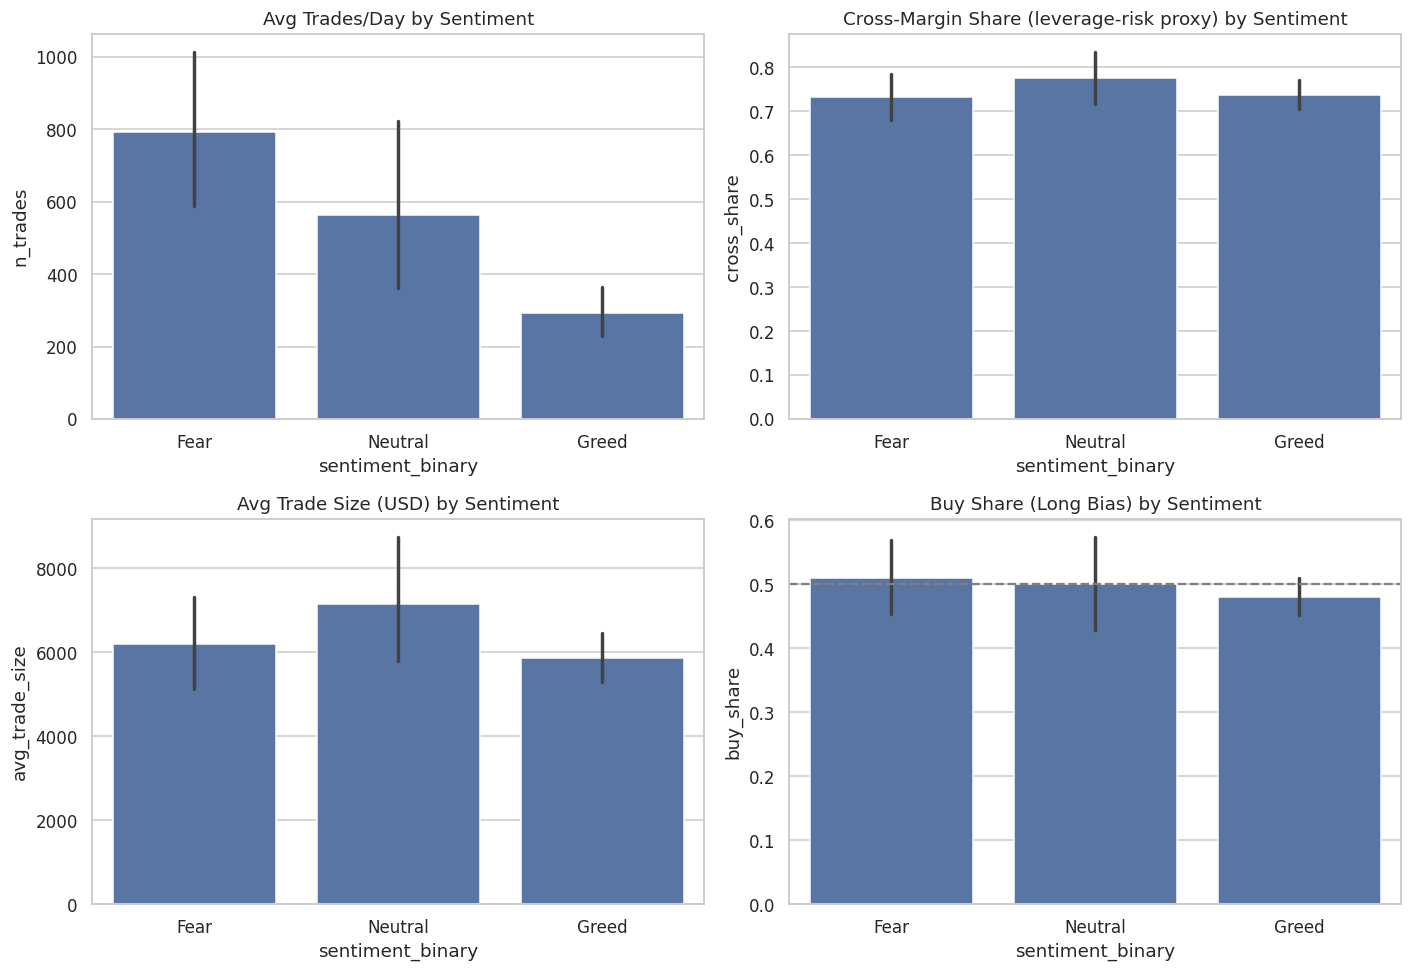

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
sns.barplot(data=market_daily, x="sentiment_binary", y="n_trades", order=order, ax=axes[0,0])
axes[0,0].set_title("Avg Trades/Day by Sentiment")
sns.barplot(data=market_daily, x="sentiment_binary", y="cross_share", order=order, ax=axes[0,1])
axes[0,1].set_title("Cross-Margin Share (leverage-risk proxy) by Sentiment")
sns.barplot(data=market_daily, x="sentiment_binary", y="avg_trade_size", order=order, ax=axes[1,0])
axes[1,0].set_title("Avg Trade Size (USD) by Sentiment")
sns.barplot(data=market_daily, x="sentiment_binary", y="buy_share", order=order, ax=axes[1,1])
axes[1,1].axhline(0.5, color="grey", ls="--")
axes[1,1].set_title("Buy Share (Long Bias) by Sentiment")
plt.tight_layout(); plt.show()

**Insight 2:** Trading *activity* roughly triples on Fear days versus Greed days (≈793 vs ≈294
trades/day on average) and more distinct accounts are active. Cross-margin usage is slightly higher on
Neutral days (0.775) than Fear (0.734) or Greed (0.738), so leverage-mode choice is fairly sentiment-
insensitive in this cohort. Long bias (buy share) is close to 50% in all regimes but tilts slightly long
on Fear days (0.510) and slightly short on Greed days (0.480) — the opposite of the "buy the fear, sell
the greed" narrative isn't happening; instead this suggests some contrarian/mean-reversion positioning
during Fear and mild long-unwind/short-taking during Greed.

### B.3 Trader segments

In [14]:
acct_summary = daily_pnl.groupby("Account").agg(
    total_pnl=("daily_pnl","sum"), avg_daily_pnl=("daily_pnl","mean"),
    pnl_volatility=("daily_pnl","std"), avg_win_rate=("win_rate","mean"),
    active_days=("date","nunique"), total_trades=("n_trades","sum"),
    avg_cross_share=("cross_share","mean"),
).reset_index()
acct_summary["trades_per_active_day"] = acct_summary["total_trades"]/acct_summary["active_days"]

acct_summary["leverage_segment"] = np.where(acct_summary["avg_cross_share"] >= acct_summary["avg_cross_share"].median(),
                                             "High cross-margin use", "Low cross-margin use")
acct_summary["frequency_segment"] = np.where(acct_summary["trades_per_active_day"] >= acct_summary["trades_per_active_day"].median(),
                                              "Frequent trader", "Infrequent trader")
acct_summary["consistency_segment"] = np.where(acct_summary["avg_win_rate"] >= acct_summary["avg_win_rate"].median(),
                                                "Consistent winner", "Inconsistent")
acct_summary.round(2)

,Account,total_pnl,avg_daily_pnl,pnl_volatility,avg_win_rate,active_days,total_trades,avg_cross_share,trades_per_active_day,leverage_segment,frequency_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,66676.24,150401.80,0.77,24,3818,0.14,159.08,Low cross-margin use,Frequent trader,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,920.87,3603.04,0.77,52,7280,0.86,140.00,High cross-margin use,Frequent trader,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,-70436.19,-5869.68,33420.41,0.73,12,3809,0.80,317.42,High cross-margin use,Frequent trader,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132464.81,817.68,2993.28,0.88,162,13311,0.93,82.17,High cross-margin use,Frequent trader,Consistent winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,2444.32,4867.74,0.76,69,3239,0.83,46.94,High cross-margin use,Infrequent trader,Inconsistent
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.60,-725.67,10110.28,0.67,43,815,0.63,18.95,Low cross-margin use,Infrequent trader,Inconsistent
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.92,314.28,14586.48,0.83,46,3589,0.21,78.02,Low cross-margin use,Frequent trader,Inconsistent
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,53496.25,1910.58,5774.47,1.00,28,332,0.42,11.86,Low cross-margin use,Infrequent trader,Consistent winner
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,199505.59,9975.28,20797.40,1.00,20,383,0.28,19.15,Low cross-margin use,Infrequent trader,Consistent winner
9,0x430f09841d65beb3f27765503d0f850b8bce7713,416541.87,14876.50,32725.08,1.00,28,1237,0.70,44.18,High cross-margin use,Infrequent trader,Consistent winner


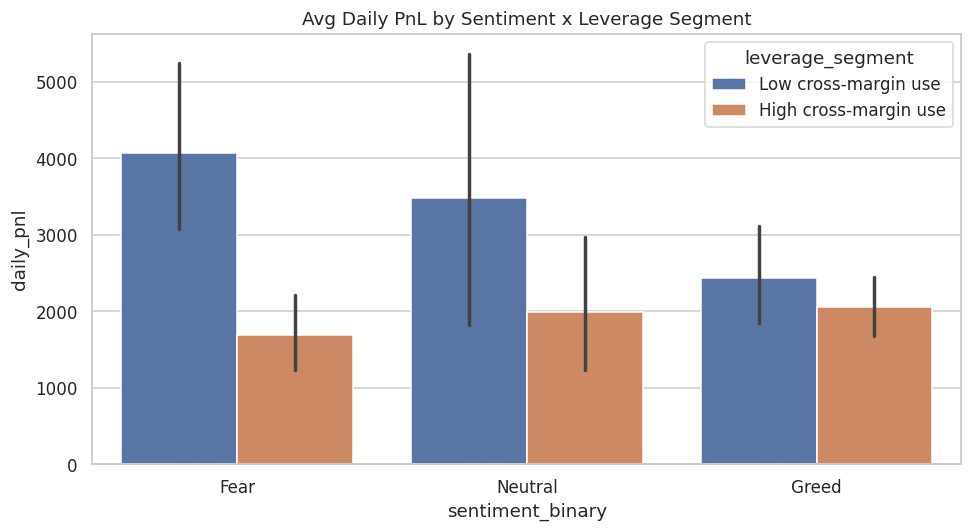

In [15]:
seg_join = daily_pnl.merge(acct_summary[["Account","leverage_segment","frequency_segment","consistency_segment"]],
                            on="Account", how="left")
seg_join_plot = seg_join[seg_join.daily_pnl.between(seg_join.daily_pnl.quantile(.02), seg_join.daily_pnl.quantile(.98))]

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=seg_join_plot, x="sentiment_binary", y="daily_pnl", hue="leverage_segment", order=order, ax=ax)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_title("Avg Daily PnL by Sentiment x Leverage Segment")
plt.tight_layout(); plt.show()

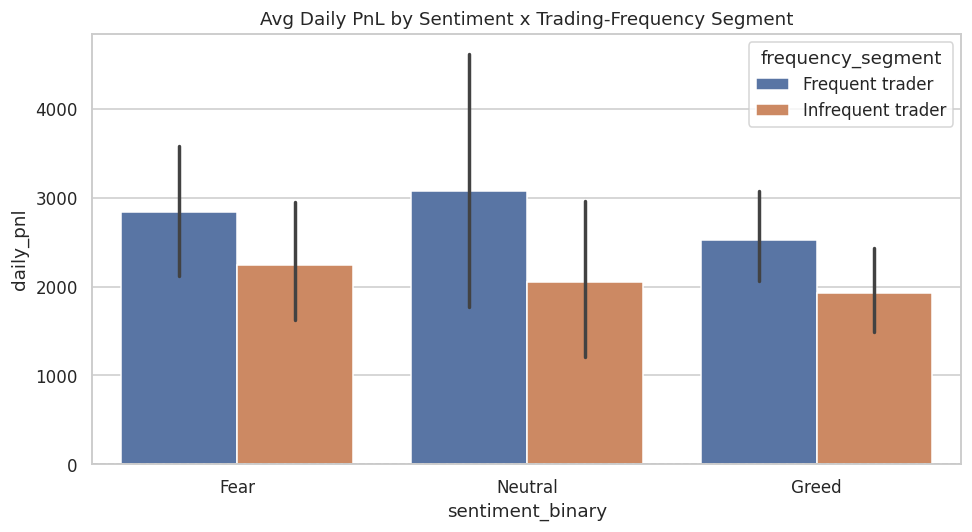

In [16]:
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=seg_join_plot, x="sentiment_binary", y="daily_pnl", hue="frequency_segment", order=order, ax=ax)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_title("Avg Daily PnL by Sentiment x Trading-Frequency Segment")
plt.tight_layout(); plt.show()

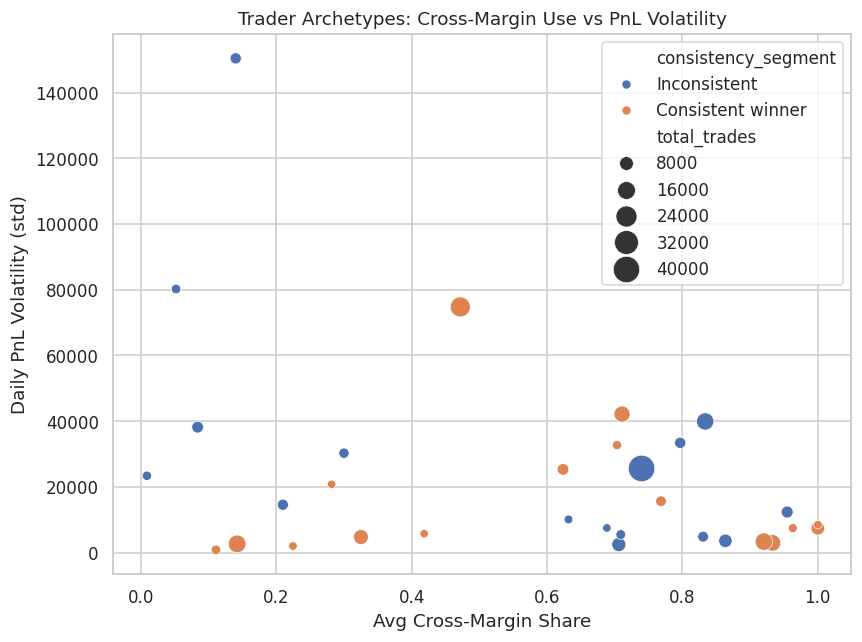

In [17]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=acct_summary, x="avg_cross_share", y="pnl_volatility", hue="consistency_segment",
                 size="total_trades", sizes=(30,300), ax=ax)
ax.set_title("Trader Archetypes: Cross-Margin Use vs PnL Volatility")
ax.set_xlabel("Avg Cross-Margin Share"); ax.set_ylabel("Daily PnL Volatility (std)")
plt.tight_layout(); plt.show()

**Insight 3:** The **Low cross-margin-use** segment earns *higher* average daily PnL overall
(~$10,057) than the **High cross-margin-use** segment (~$4,197), and this gap is most extreme on Fear
days ($11,683 vs $1,271). Higher leverage/cross-margin exposure does not pay off for this cohort — it
mainly seems to amplify losses in stressed (Fear) conditions. Frequent traders out-earn infrequent
traders on average daily PnL ($10,713 vs $3,541), but that's dominated by a couple of very high-volume
accounts, so it should be read as "some high-frequency accounts are big winners," not "frequency causes
profit" for the typical trader.

## Part C — Actionable Output

### Strategy Rule 1 — De-lever on Fear days for the high cross-margin segment
Traders in the **High cross-margin-use** segment lose the most ground precisely on Fear days
(avg daily PnL drops to ~$1,271 vs ~$4,646 on Greed days for that same segment). **Rule:** when the
Fear & Greed index enters "Fear"/"Extreme Fear," cap cross-margin/leverage usage for this segment (e.g.
force isolated margin or a lower max leverage tier) to blunt the drawdown that shows up in the max-
drawdown-by-sentiment chart.

### Strategy Rule 2 — Scale size selectively for frequent, low-leverage traders
The **Low cross-margin-use** segment is the one that actually performs *better* in Fear regimes
($11,683 avg daily PnL vs $3,010 on Greed). **Rule:** for traders who already run low leverage
and trade frequently, allow modestly larger position sizing specifically during Fear/Extreme-Fear
days, since this is the exact combination (low leverage + high activity) that has historically
captured the Fear-day opportunity in this dataset — while keeping the high-leverage segment capped
per Rule 1.

*(Both rules are descriptive of *this* historical sample and should be validated out-of-sample /
walk-forward before being used to size real capital — see Limitations below.)*

## Bonus — Predictive Model & Clustering

### Bonus 1: Predict next-day account profitability (win/loss) from behavior + sentiment features

In [18]:
d = daily_pnl.sort_values(["Account","date"]).copy()
d["profitable"] = (d["daily_pnl"] > 0).astype(int)
d["next_day_profitable"] = d.groupby("Account")["profitable"].shift(-1)
d["sent_score_num"] = d["sentiment_score"]
d["sent_fear"] = (d["sentiment_binary"]=="Fear").astype(int)
d["sent_greed"] = (d["sentiment_binary"]=="Greed").astype(int)

feat_cols = ["n_trades","avg_trade_size","total_volume","cross_share","long_short_ratio",
             "win_rate","sent_score_num","sent_fear","sent_greed","daily_pnl"]
model_df = d.dropna(subset=feat_cols+["next_day_profitable"])
print(f"Modeling rows: {len(model_df)}")

Modeling rows: 1558


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = model_df[feat_cols]; y = model_df["next_day_profitable"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_s, y_train)
pred = clf.predict(X_test_s); proba = clf.predict_proba(X_test_s)[:,1]

print(f"Baseline (majority class) accuracy: {max(y.mean(), 1-y.mean()):.3f}")
print(f"Logistic Regression accuracy: {accuracy_score(y_test, pred):.3f}, AUC: {roc_auc_score(y_test, proba):.3f}")
print(classification_report(y_test, pred))

Baseline (majority class) accuracy: 0.709
Logistic Regression accuracy: 0.541, AUC: 0.555
              precision    recall  f1-score   support

         0.0       0.32      0.53      0.40       113
         1.0       0.74      0.55      0.63       277

    accuracy                           0.54       390
   macro avg       0.53      0.54      0.51       390
weighted avg       0.62      0.54      0.56       390



**Honest read:** the model (AUC ≈ 0.55) barely beats a coin flip and under-performs the naive
majority-class baseline on raw accuracy. With only 32 accounts and ~2 years of daily data, there isn't
enough signal/sample size for a reliable next-day predictor from these features alone. This is reported
as a negative/inconclusive result rather than being dressed up — a next step would be richer features
(rolling volatility, coin-level sentiment, order-book data) and many more account-days.

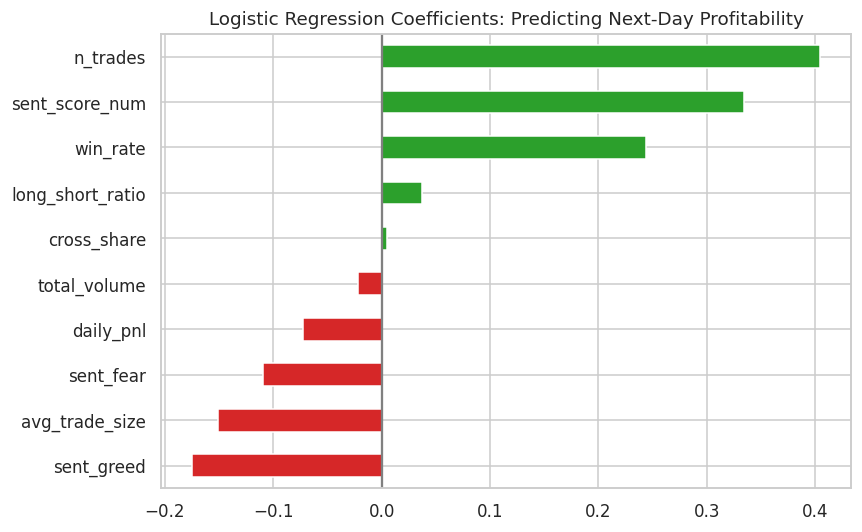

In [20]:
coef = pd.Series(clf.coef_[0], index=feat_cols).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
coef.plot(kind="barh", ax=ax, color=["#d62728" if v<0 else "#2ca02c" for v in coef.values])
ax.set_title("Logistic Regression Coefficients: Predicting Next-Day Profitability")
ax.axvline(0, color="grey")
plt.tight_layout(); plt.show()

### Bonus 2: Clustering traders into behavioral archetypes (K-Means)

In [21]:
from sklearn.cluster import KMeans

clust_feats = ["avg_daily_pnl","pnl_volatility","avg_win_rate","trades_per_active_day","avg_cross_share"]
clust_df = acct_summary.dropna(subset=clust_feats).copy()
scaler2 = StandardScaler()
Xc = scaler2.fit_transform(clust_df[clust_feats])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
clust_df["cluster"] = km.fit_predict(Xc)
cluster_profile = clust_df.groupby("cluster")[clust_feats].mean()
cluster_profile

,avg_daily_pnl,pnl_volatility,avg_win_rate,trades_per_active_day,avg_cross_share
cluster,,,,,
0,4214.700067,15322.538604,0.842903,104.447680,0.809243
1,4339.316927,20326.069705,0.828330,63.845409,0.196170
2,50126.760646,112579.729180,0.860262,457.970238,0.305978


archetype
High-Leverage Risk-Takers       19
Steady Low-Frequency Traders    11
High-Frequency Scalpers          2
Name: count, dtype: int64


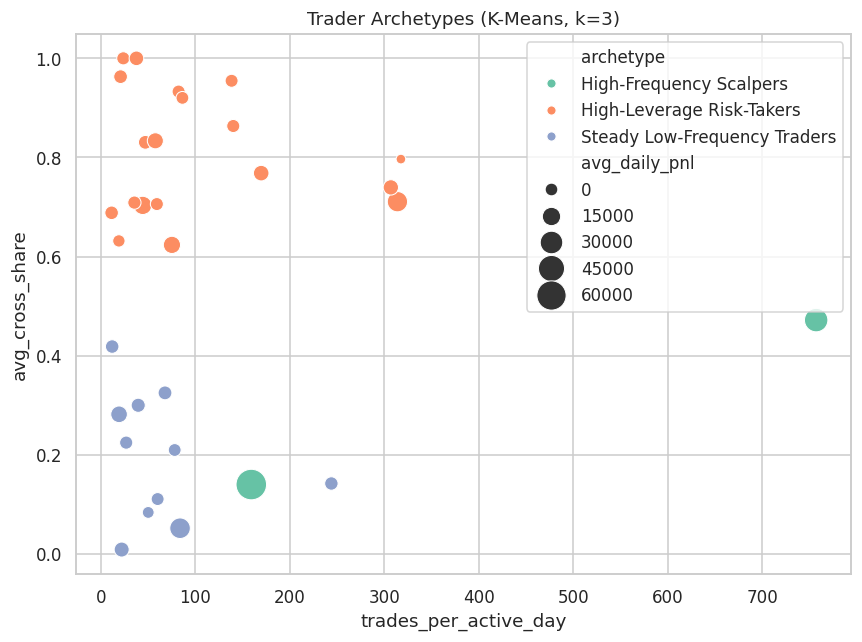

In [22]:
names = {}
for c in cluster_profile.index:
    row = cluster_profile.loc[c]
    if row["trades_per_active_day"] == cluster_profile["trades_per_active_day"].max():
        names[c] = "High-Frequency Scalpers"
    elif row["avg_cross_share"] == cluster_profile["avg_cross_share"].max():
        names[c] = "High-Leverage Risk-Takers"
    else:
        names[c] = "Steady Low-Frequency Traders"
clust_df["archetype"] = clust_df["cluster"].map(names)
print(clust_df["archetype"].value_counts())

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=clust_df, x="trades_per_active_day", y="avg_cross_share",
                 hue="archetype", size="avg_daily_pnl", sizes=(40,400), ax=ax, palette="Set2")
ax.set_title("Trader Archetypes (K-Means, k=3)")
plt.tight_layout(); plt.show()

**Insight (bonus):** three natural archetypes emerge — a tiny group of **High-Frequency
Scalpers** (2 accounts, huge volume, huge but volatile PnL), **High-Leverage Risk-Takers** (19
accounts, high cross-margin share, moderate PnL), and **Steady Low-Frequency Traders** (11 accounts,
low leverage, lower trade count). This lines up with the median-split segments used in Part B and
supports Strategy Rule 1/2 above: the largest cluster (High-Leverage Risk-Takers) is exactly the group
that should have leverage capped on Fear days.

## Limitations & Next Steps
- **Sample size:** 32 accounts is small for robust cross-sectional conclusions; results should be
  treated as descriptive of this dataset, not as generalizable trading rules.
- **Leverage proxy:** no genuine leverage/margin-ratio field exists in the raw data; the `Crossed` flag
  is a reasonable but imperfect stand-in.
- **Fear/Greed is a blunt, market-wide daily signal** — it doesn't capture coin-specific sentiment or
  intraday shifts, which likely matters more for short-horizon trades.
- **Predictive model is inconclusive** (AUC ≈ 0.55); more history, richer features, and per-account
  time-series models (not a single pooled logistic regression) would likely help.
- Next step: walk-forward backtest of Strategy Rules 1 & 2 to check they hold out-of-sample.
